<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica3Quest%C3%A3o2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

b[n] = [ 1.      0.      0.49    0.      0.      0.      0.2401  0.     -0.0576
  0.     -0.0282  0.     -0.0138]
a[n] = [1.]


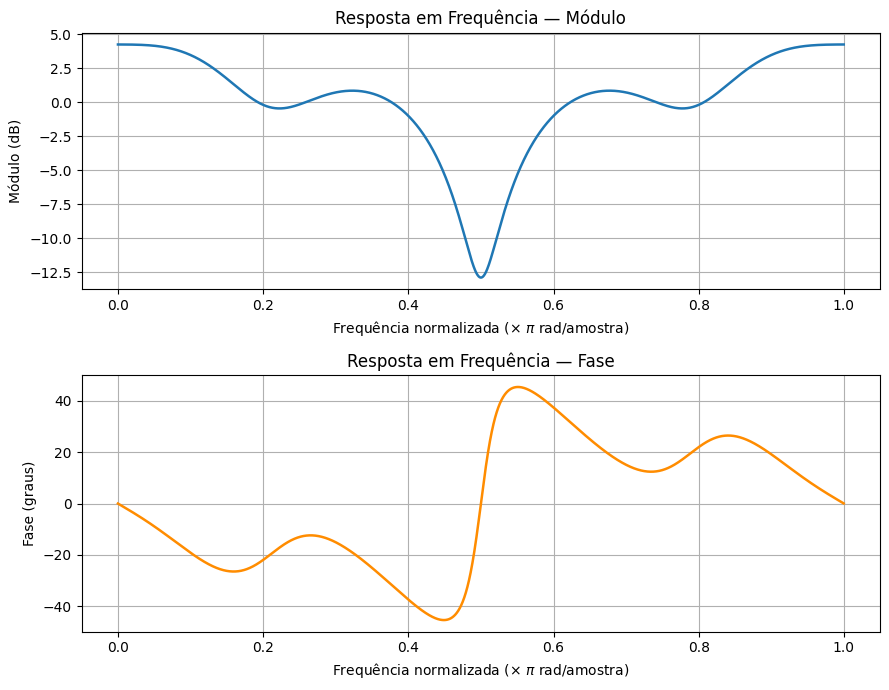

Ganho k = 1.0

Zeros (12):
  -0.6197+0.4818j    |z| = 0.7850    ângulo = 142.13°
  -0.6197-0.4818j    |z| = 0.7850    ângulo = -142.13°
  -0.6679+0.0000j    |z| = 0.6679    ângulo = 180.00°
  -0.0000+0.9336j    |z| = 0.9336    ângulo = 90.00°
  -0.0000-0.9336j    |z| = 0.9336    ângulo = -90.00°
  0.6197+0.4818j    |z| = 0.7850    ângulo = 37.87°
  0.6197-0.4818j    |z| = 0.7850    ângulo = -37.87°
  0.6679+0.0000j    |z| = 0.6679    ângulo = 0.00°
  -0.2467+0.4949j    |z| = 0.5530    ângulo = 116.49°
  -0.2467-0.4949j    |z| = 0.5530    ângulo = -116.49°
  0.2467+0.4949j    |z| = 0.5530    ângulo = 63.51°
  0.2467-0.4949j    |z| = 0.5530    ângulo = -63.51°

Polos (12):
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000
  0.0000


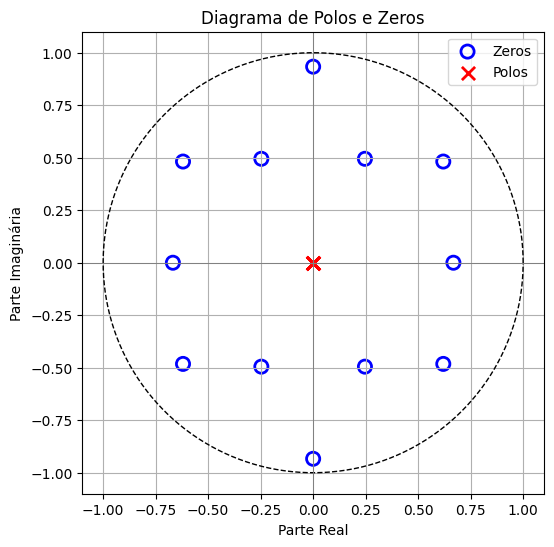

Frequência de amostragem: 8192 Hz
Número de amostras: 73113  (duração = 8.92 s)

Áudio original:


max |x[n]| = 0.8000
max |y[n]| = 1.1164

Áudio filtrado (y[n], normalizado para reprodução):


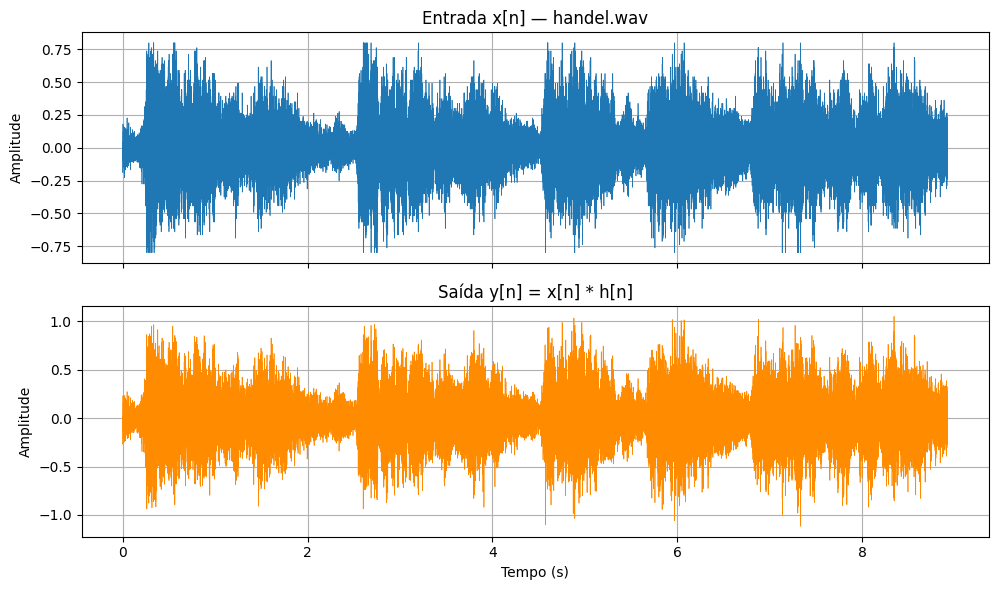

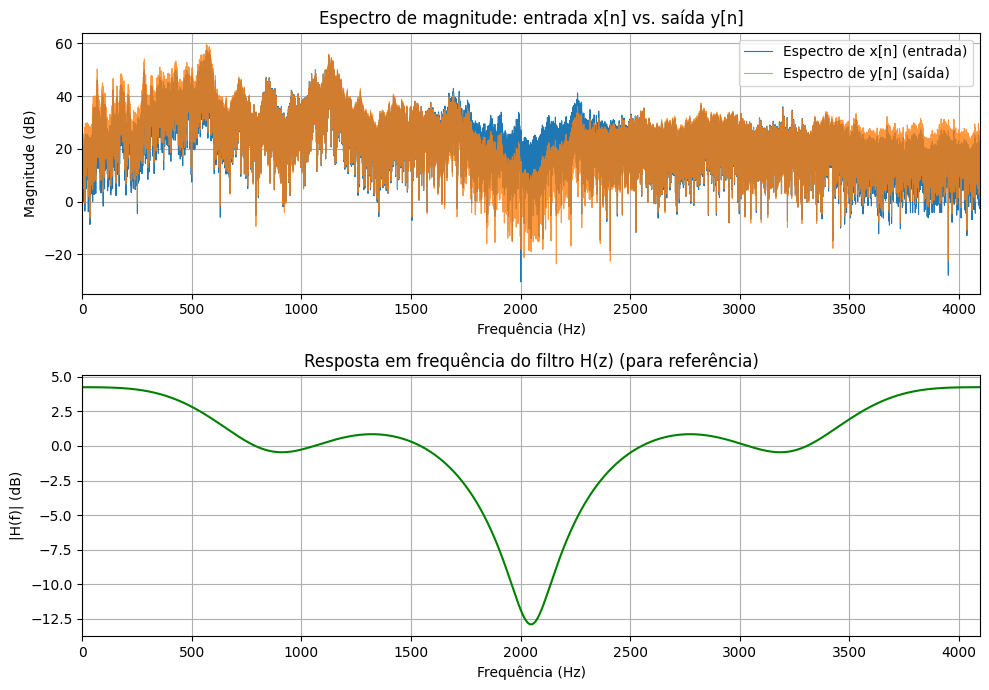

Energia de x[n]: 2815.43
Energia de y[n]: 4192.51
Razão Ey/Ex: 1.489

Centroide espectral de x[n]: 1297.5 Hz
Centroide espectral de y[n]: 1197.5 Hz

f =     0.0 Hz  ->  |H| = 1.6305  (4.25 dB)
f =   567.0 Hz  ->  |H| = 1.2916  (2.22 dB)
f =  1024.0 Hz  ->  |H| = 0.9816  (-0.16 dB)
f =  2048.0 Hz  ->  |H| = 0.2267  (-12.89 dB)
f =  3000.0 Hz  ->  |H| = 1.0216  (0.19 dB)
f =  4096.0 Hz  ->  |H| = 1.6305  (4.25 dB)


In [3]:
# ================== Bibliotecas ==================
import numpy as np                 # vetores e operações numéricas
import matplotlib.pyplot as plt    # gráficos
from scipy import signal           # freqz, tf2zpk, lfilter, etc.

# ================== Questão 1 — H(z) ==================
# Coeficientes do numerador b[n] (multiplicam as potências z^-n)
# H(z) = 1 + 0.49 z^-2 + 0.2401 z^-6 - 0.0576 z^-8 - 0.0282 z^-10 - 0.0138 z^-12
b = np.zeros(13)        # vetor com 13 posições: índices 0 (z^0) até 12 (z^-12)
b[0]  = 1               # coeficiente de z^0
b[2]  = 0.49            # coeficiente de z^-2
b[6]  = 0.2401          # coeficiente de z^-6
b[8]  = -0.0576         # coeficiente de z^-8
b[10] = -0.0282         # coeficiente de z^-10
b[12] = -0.0138         # coeficiente de z^-12

# Denominador: o sistema é FIR (sem realimentação/recursão) -> a = 1
a = np.array([1.0])

print("b[n] =", b)
print("a[n] =", a)

# --- Resposta em frequência ---
# freqz calcula H(e^jw) em 4096 pontos de frequência entre 0 e pi
w, H = signal.freqz(b, a, worN=4096)

modulo_dB  = 20 * np.log10(np.abs(H) + 1e-12)   # módulo em dB (1e-12 evita log(0))
fase_graus = np.degrees(np.angle(H))            # fase em graus

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))

ax1.plot(w / np.pi, modulo_dB, linewidth=1.8)
ax1.set_title("Resposta em Frequência — Módulo")
ax1.set_xlabel(r"Frequência normalizada ($\times\ \pi$ rad/amostra)")
ax1.set_ylabel("Módulo (dB)")
ax1.grid(True)

ax2.plot(w / np.pi, fase_graus, linewidth=1.8, color="darkorange")
ax2.set_title("Resposta em Frequência — Fase")
ax2.set_xlabel(r"Frequência normalizada ($\times\ \pi$ rad/amostra)")
ax2.set_ylabel("Fase (graus)")
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Polos e zeros ---
# Como H(z) só tem potências negativas de z (sistema FIR), a e b precisam
# ter o mesmo comprimento para que tf2zpk exponha corretamente os polos
# "escondidos" na origem (um polo em z=0 para cada atraso do sistema).
N = max(len(a), len(b))
b_pad = np.concatenate([b, np.zeros(N - len(b))])
a_pad = np.concatenate([a, np.zeros(N - len(a))])

# tf2zpk devolve: zeros (raízes do numerador), polos (raízes do denominador) e ganho k
zeros, polos, k = signal.tf2zpk(b_pad, a_pad)

print(f"Ganho k = {k}\n")
print(f"Zeros ({len(zeros)}):")
for z in zeros:
    print(f"  {z:.4f}    |z| = {abs(z):.4f}    ângulo = {np.degrees(np.angle(z)):.2f}°")
print(f"\nPolos ({len(polos)}):")
for p in polos:
    print(f"  {p:.4f}")

# --- Diagrama de polos e zeros ---
def diagrama_polos_zeros(zeros, polos, titulo="Diagrama de Polos e Zeros"):
    """Plota polos (x) e zeros (o) de um sistema discreto no plano z,
    junto com o círculo unitário (referência de estabilidade)."""
    fig, ax = plt.subplots(figsize=(6, 6))
    theta = np.linspace(0, 2 * np.pi, 512)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)   # círculo unitário
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.axvline(0, color='gray', linewidth=0.7)
    ax.scatter(zeros.real, zeros.imag, marker='o', s=90,
               facecolors='none', edgecolors='b', linewidths=2, label='Zeros')
    ax.scatter(polos.real, polos.imag, marker='x', s=90,
               color='r', linewidths=2, label='Polos')
    ax.set_xlabel("Parte Real"); ax.set_ylabel("Parte Imaginária")
    ax.set_title(titulo); ax.set_aspect('equal'); ax.grid(True); ax.legend()
    plt.show()

diagrama_polos_zeros(zeros, polos)

# ================== Questão 2 — resposta ao áudio handel.wav ==================
import urllib.request               # para baixar o arquivo direto do GitHub
from scipy.io import wavfile        # ler/escrever arquivos .wav
from IPython.display import Audio, display   # player de áudio no notebook

# Baixa o handel.wav do repositório do GitHub indicado
url = "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_03/Audios_Usados/handel.wav"
urllib.request.urlretrieve(url, "handel.wav")

# Lê o arquivo: fs = frequência de amostragem, x_int = amostras em inteiro (int16)
fs, x_int = wavfile.read("handel.wav")

# Normaliza as amostras para float64 no intervalo [-1, 1]
x = x_int.astype(np.float64) / np.iinfo(x_int.dtype).max

print(f"Frequência de amostragem: {fs} Hz")
print(f"Número de amostras: {len(x)}  (duração = {len(x)/fs:.2f} s)")
print("\nÁudio original:")
display(Audio(x, rate=fs))

# --- Filtra o áudio por H(z) ---
# lfilter resolve a equação de diferenças y[n] = b[0]x[n] + b[1]x[n-1] + ... + b[12]x[n-12]
y = signal.lfilter(b, a, x)

print(f"max |x[n]| = {np.max(np.abs(x)):.4f}")
print(f"max |y[n]| = {np.max(np.abs(y)):.4f}")   # pode passar de 1 (ganho do filtro > 1 em parte da faixa)

y_norm = y / np.max(np.abs(y))   # normaliza só para ouvir/salvar sem "clipping"
print("\nÁudio filtrado (y[n], normalizado para reprodução):")
display(Audio(y_norm, rate=fs))

wavfile.write("handel_filtrado.wav", fs, (y_norm * 32767).astype(np.int16))

# --- Formas de onda no tempo ---
t = np.arange(len(x)) / fs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(t, x, linewidth=0.5); ax1.set_title("Entrada x[n] — handel.wav")
ax1.set_ylabel("Amplitude"); ax1.grid(True)
ax2.plot(t, y, linewidth=0.5, color="darkorange"); ax2.set_title("Saída y[n] = x[n] * h[n]")
ax2.set_xlabel("Tempo (s)"); ax2.set_ylabel("Amplitude"); ax2.grid(True)
plt.tight_layout(); plt.show()

# --- Espectros de entrada e saída ---
N = len(x)
X = np.fft.rfft(x); Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(N, d=1/fs)
X_dB = 20 * np.log10(np.abs(X) + 1e-12)
Y_dB = 20 * np.log10(np.abs(Y) + 1e-12)

w_hz, H_hz = signal.freqz(b, a, worN=8192, fs=fs)   # resposta em frequência do filtro em Hz reais
H_dB = 20 * np.log10(np.abs(H_hz) + 1e-12)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax1.plot(freqs, X_dB, label="Espectro de x[n] (entrada)", linewidth=0.8)
ax1.plot(freqs, Y_dB, label="Espectro de y[n] (saída)", linewidth=0.8, alpha=0.8)
ax1.set_xlim(0, fs/2); ax1.set_xlabel("Frequência (Hz)"); ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("Espectro de magnitude: entrada x[n] vs. saída y[n]"); ax1.legend(); ax1.grid(True)

ax2.plot(w_hz, H_dB, color="green")
ax2.set_xlim(0, fs/2); ax2.set_xlabel("Frequência (Hz)"); ax2.set_ylabel("|H(f)| (dB)")
ax2.set_title("Resposta em frequência do filtro H(z) (para referência)"); ax2.grid(True)
plt.tight_layout(); plt.show()

# --- Números para comentar os resultados ---
Ex = np.sum(np.abs(x)**2); Ey = np.sum(np.abs(y)**2)
print(f"Energia de x[n]: {Ex:.2f}")
print(f"Energia de y[n]: {Ey:.2f}")
print(f"Razão Ey/Ex: {Ey/Ex:.3f}\n")

centroide_x = np.sum(freqs * np.abs(X)) / np.sum(np.abs(X))
centroide_y = np.sum(freqs * np.abs(Y)) / np.sum(np.abs(Y))
print(f"Centroide espectral de x[n]: {centroide_x:.1f} Hz")
print(f"Centroide espectral de y[n]: {centroide_y:.1f} Hz\n")

for f0 in [0, 567, 1024, 2048, 3000, fs/2]:
    idx = np.argmin(np.abs(w_hz - f0))
    print(f"f = {f0:7.1f} Hz  ->  |H| = {np.abs(H_hz[idx]):.4f}  ({H_dB[idx]:.2f} dB)")

Aplicando esse mesmo H(z) ao áudio (fs = 8192 Hz, 73113 amostras, ≈8,9 s), o sinal de saída y[n] tem energia cerca de 1,49 vez maior que a de x[n] (Ey/Ex ≈ 1,489), reflexo direto do ganho do filtro ser maior que 0 dB em boa parte da faixa de áudio. Isso também faz a amplitude de pico de y[n] ultrapassar 1,0 (chega a ≈1,12/1,16, visível tanto nos números quanto no gráfico de forma de onda, onde a saída em laranja claramente extrapola a faixa da entrada em azul) — por isso foi necessário normalizar antes de reproduzir/salvar o áudio, evitando clipping.

O espectro de saída (comparado ao de entrada, e à curva de |H(f)| logo abaixo, usada como referência) mostra exatamente o padrão previsto na Questão 1, agora na escala real de frequência: leve reforço perto das extremidades da banda de áudio (perto de 0 Hz e de fs/2 = 4096 Hz), resposta praticamente neutra por volta de 1 kHz, e uma atenuação bem marcada por volta de fs/4 = 2048 Hz (-12,9 dB) — visível no gráfico como um vale nítido no espectro da saída exatamente nessa região.

A componente de maior energia do áudio original está por volta de 567 Hz, uma faixa onde o filtro tem ganho positivo (~+2,2 dB), então essa componente não só é preservada como é levemente realçada na saída. Isso é coerente com o pequeno deslocamento do centróide espectral, de ≈1297,5 Hz (entrada) para ≈1197,5 Hz (saída): a energia se concentra um pouco mais nas frequências baixas, resultado combinado do reforço perto de 0 Hz e da forte atenuação perto de 2 kHz.

Em suma: os dois experimentos convergem para a mesma conclusão sobre o comportamento de H(z) — um filtro FIR estável, com resposta em frequência periódica de período π (decorrência de depender só de z⁻²) e um comportamento de rejeita-faixa centrado em π/2 (2048 Hz, no caso do áudio a 8192 Hz), e o efeito desse filtro sobre um sinal real (o áudio) confirma exatamente essa previsão teórica: atenuação seletiva em torno de 2 kHz, leve ganho nas extremidades da banda, e aumento geral de energia do sinal filtrado.